In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)



print("All ML models imported successfully!")

All ML models imported successfully!


In [3]:

SAMPLE_SIZE = 15000   # keeps first run to a couple minutes; raise later once it works
RANDOM_STATE = 42
KNN_NEIGHBORS = 5

In [4]:
train_df = pd.read_csv("dataset/train_processed.csv")
test_df = pd.read_csv("dataset/test_processed.csv")
if SAMPLE_SIZE is not None and len(train_df) > SAMPLE_SIZE:
    train_df, _ = train_test_split(
        train_df, train_size=SAMPLE_SIZE,
        stratify=train_df["binary_label"], random_state=RANDOM_STATE
    )

feature_cols = [c for c in train_df.columns if c not in ("label", "binary_label")]
X_train, y_train = train_df[feature_cols].values, train_df["binary_label"].values
X_test, y_test = test_df[feature_cols].values, test_df["binary_label"].values

print(f"Train samples: {len(X_train)}  |  Test samples: {len(X_test)}")


Train samples: 15000  |  Test samples: 22544


In [5]:
class HybridSVMKNN:

    def __init__(self, knn_neighbors=5, random_state=42):
        self.svm = SVC(
            kernel="rbf",
            probability=True,
            random_state=random_state
        )

        self.knn = KNeighborsClassifier(
            n_neighbors=knn_neighbors,
            weights="distance"
        )

    def fit(self, X, y):
        self.svm.fit(X, y)
        self.knn.fit(X, y)
        return self

    def predict_proba(self, X):

        svm_proba = self.svm.predict_proba(X)[:, 1]
        knn_proba = self.knn.predict_proba(X)[:, 1]

        hybrid_proba = (
            svm_proba + knn_proba
        ) / 2.0

        return hybrid_proba

    def predict(self, X):

        hybrid_proba = self.predict_proba(X)

        return (
            hybrid_proba >= 0.5
        ).astype(int)

#### train the hybrid model

In [6]:
t0 = time.time()
hybrid = HybridSVMKNN(knn_neighbors=KNN_NEIGHBORS, random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"Trained in {time.time()-t0:.1f}s")

joblib.dump(hybrid, "models/hybrid_svm_knn.joblib")

d:\Programming\Research paper implementation\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Trained in 10.0s


['models/hybrid_svm_knn.joblib']

In [7]:
## Training the baseline models
dt = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train, y_train)
svm_only = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE).fit(X_train, y_train)
knn_only = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, weights="distance").fit(X_train, y_train)

joblib.dump(dt,"models/decision_tree.joblib")
joblib.dump(lr,  "models/logistic_regression.joblib")
joblib.dump(svm_only,"models/svm_only.joblib")
joblib.dump(knn_only,"models/knn_only.joblib")
print("Baselines trained.")

d:\Programming\Research paper implementation\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Baselines trained.


In [8]:
## Evaluating the models
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = []
y_preds = {}

for name, model in [("Hybrid SVM-KNN (Proposed)", hybrid), ("Decision Tree", dt),
                     ("Logistic Regression", lr), ("SVM only", svm_only), ("KNN only", knn_only)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if name == "Hybrid SVM-KNN (Proposed)" else model.predict_proba(X_test)[:, 1]
    results.append(evaluate(name, y_test, pred, proba))
    y_preds[name] = pred

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df.to_csv("results/metrics_table.csv")
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Hybrid SVM-KNN (Proposed),0.7678,0.9212,0.6475,0.7605,0.9310
Decision Tree,0.7829,0.9693,0.6389,0.7701,0.8061
Logistic Regression,0.7526,0.9259,0.6145,0.7387,0.9048
SVM only,0.7575,0.9794,0.5864,0.7336,0.9307
KNN only,0.7746,0.9230,0.6589,0.7689,0.8148


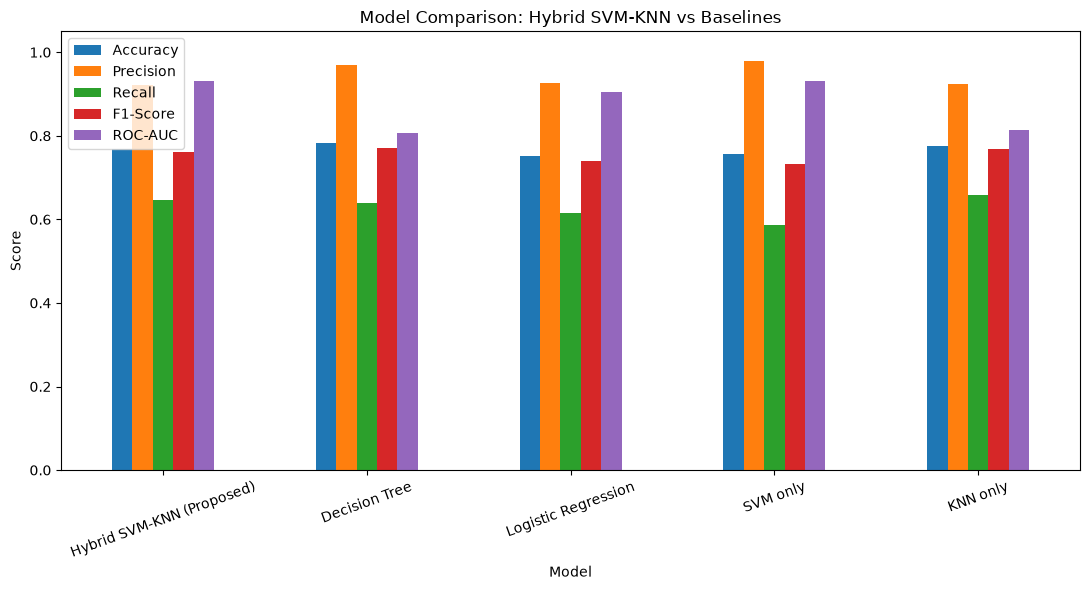

In [9]:
ax = results_df.plot(kind="bar", figsize=(11, 6), rot=20)
ax.set_title("Model Comparison: Hybrid SVM-KNN vs Baselines")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("results/metric_comparison.png", dpi=150)
plt.show()

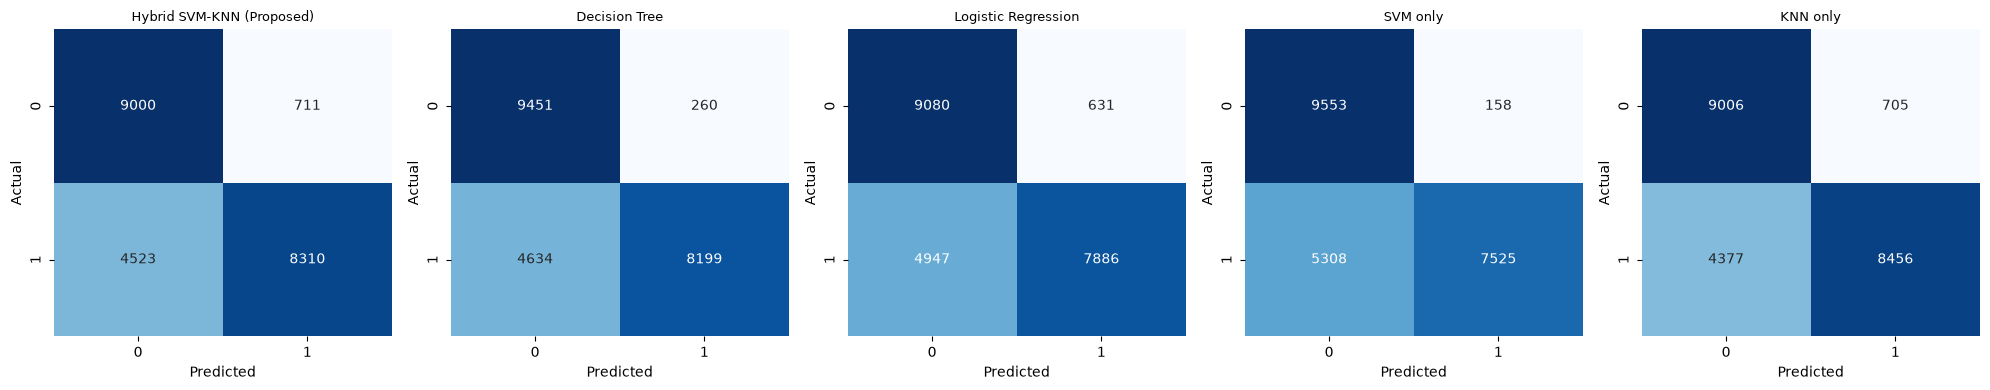

In [10]:
#confusion matrix for the proposed model
fig, axes = plt.subplots(1, len(y_preds), figsize=(4 * len(y_preds), 4))
for ax, (name, pred) in zip(axes, y_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=150)
plt.show()

In [11]:
import joblib

hybrid_loaded = joblib.load("models/hybrid_svm_knn.joblib")

print(type(hybrid_loaded))
print("Model loaded successfully.")

<class '__main__.HybridSVMKNN'>
Model loaded successfully.
